In [1]:
# import everything

from manim import *
from nn_vis_funcs import *

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from skimage.measure import find_contours

from collections import OrderedDict

import torch
from torch import nn

# check that GPU is recognized
print("Does PyTorch recognize the GPU?","Yes" if torch.cuda.is_available() else "No")
device="cuda" if torch.cuda.is_available() else "cpu"

Does PyTorch recognize the GPU? No


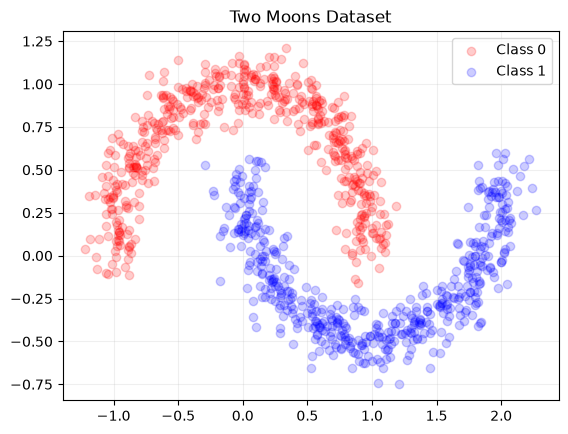

In [2]:
# Generate the Two Moons dataset
x_data, y_data = make_moons(
    n_samples=1000,
    shuffle=True,
    noise=0.1,
    random_state=42
)

# Plot the Two Moons dataset
class_colors = ["red", "blue"]
for i in range(len(np.unique(y_data))):
    plt.scatter(
        x_data[y_data == i, 0],
        x_data[y_data == i, 1],
        color=class_colors[i],
        alpha=0.2,
        label="Class "+str(i)
    )

plt.grid(alpha=0.2)
plt.legend()
plt.title("Two Moons Dataset")
plt.show()

In [3]:
# Define a single layer neural network
model_1l = nn.Sequential(OrderedDict([
    ("0_linear", nn.Linear(2, 5)),
    ("1_relu", nn.ReLU()),
    ("2_linear", nn.Linear(5,1)),
    ("3_sigmoid", nn.Sigmoid())
])
)

model_1l.to(device)
print(model_1l)
print("Number of trainable parameters:", sum(p.numel()
      for p in model_1l.parameters() if p.requires_grad))

Sequential(
  (0_linear): Linear(in_features=2, out_features=5, bias=True)
  (1_relu): ReLU()
  (2_linear): Linear(in_features=5, out_features=1, bias=True)
  (3_sigmoid): Sigmoid()
)
Number of trainable parameters: 21


In [4]:
# Define a 2 hidden layer neural network

model_2l = nn.Sequential(OrderedDict([
    ("0_linear", nn.Linear(2, 5)),
    ("1_relu", nn.ReLU()),
    ("2_linear", nn.Linear(5,5)),
    ("3_relu", nn.ReLU()),
    ("4_linear", nn.Linear(5,1)),
    ("5_sigmoid", nn.Sigmoid())
])
)

model_2l.to("cpu")
print(model_2l)
print("Number of trainable parameters:", sum(p.numel()
      for p in model_2l.parameters() if p.requires_grad))

Sequential(
  (0_linear): Linear(in_features=2, out_features=5, bias=True)
  (1_relu): ReLU()
  (2_linear): Linear(in_features=5, out_features=5, bias=True)
  (3_relu): ReLU()
  (4_linear): Linear(in_features=5, out_features=1, bias=True)
  (5_sigmoid): Sigmoid()
)
Number of trainable parameters: 51


In [5]:
# load data into torch
class TwoMoons(torch.utils.data.Dataset):
    def __init__(self, x_data, y_data):
        self.X = torch.from_numpy(x_data).to(device)
        self.Y = torch.from_numpy(y_data).to(device)

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return [self.X[idx], self.Y[idx]]

# Create the training data as a DataLoader Object
two_moons = TwoMoons(x_data, y_data)
train_data = torch.utils.data.DataLoader(two_moons, batch_size=100)

In [6]:
# set up loss for training

# Define Loss Function and Optimizer
loss_function = nn.MSELoss()
optimizer_1l = torch.optim.SGD(model_1l.parameters(), lr=1e-1, momentum=0.9)
optimizer_2l = torch.optim.SGD(model_2l.parameters(), lr=1e-1, momentum=0.9)

def init_weights(model):
    def reset_weights(m):
        if isinstance(m,nn.Linear) or isinstance(m,nn.BatchNorm1d):
            m.reset_parameters()
    model.apply(reset_weights)

In [ ]:
# train function

def train(model, data, num_epochs=50, batch_size=100, show_loss=True, set_seed=42):

    loss_function = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)

    # 1. Initialization

    torch.manual_seed(set_seed)
    init_weights(model)

    loss_history = np.zeros((num_epochs))
    accuracy_history = np.zeros((num_epochs))

    initial_preds = model(data.X.float())
    initial_loss = loss_function(initial_preds, data.Y.unsqueeze(1).float())
    initial_acc = torch.eq(initial_preds.squeeze(
        1).round().bool(), data.Y.bool()).sum()
    
    train_data = torch.utils.data.DataLoader(data, batch_size=batch_size)

    if show_loss:
        print(f"Initial Loss: {initial_loss}")
        print(f"Initial Accuracy: {initial_acc/len(data)} \n")

    #2. Learning
    for epoch in range(num_epochs):
        running_loss = 0
        num_correct = 0
        total_samples = 0
        
        # TO OLIVE: this goes through each datapoint individually, instead of taking the gradient across the entire dataset. 
        # Is there a reason to do it this way? 
        # after talking: can change it to look at all data at once
        for i, (inputs, targets) in enumerate(train_data):
            optimizer.zero_grad()
            predictions = model_2l(inputs.float())
            loss = loss_function(predictions, targets.unsqueeze(1).float())
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            num_correct += torch.eq(predictions.squeeze(1).round().bool(),
                                    targets.bool()).sum()
            total_samples += targets.size(0)

        loss_history[epoch] = running_loss/len(train_data)
        accuracy_history[epoch] = num_correct/total_samples

        if show_loss:
            print(
                f"Epoch: {epoch+1:02d}/{num_epochs} | Loss: {loss_history[epoch]:.5f} \t | Accuracy: {accuracy_history[epoch]:.5f}")
        
    return model

In [13]:
# Model 1 training
model_1l = train(model_1l, two_moons)

Initial Loss: 0.25386035442352295
Initial Accuracy: 0.5 

Epoch: 01/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 02/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 03/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 04/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 05/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 06/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 07/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 08/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 09/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 10/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 11/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 12/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 13/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 14/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 15/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 16/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 17/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 18/50 | Loss: 0.00404 	 | Accuracy: 0.99900
Epoch: 19/50 | Loss: 0.0

In [9]:
# Set up grid to plot decision boundary

x0_grid = np.linspace(-1.5, 2.5, num=100)
x1_grid = np.linspace(-1, 1.5, num=100)

pred_grid = torch.from_numpy(np.array(np.meshgrid(x0_grid, x1_grid)))
pred_grid = pred_grid.to("cpu")
pred_array = torch.transpose(
    torch.reshape(pred_grid, (2, pred_grid.shape[1]*pred_grid.shape[2])), 0, 1
)


def makeGridPrediction(model, pred_array):
    model_array_preds = model(pred_array.float())

    model_grid_preds = torch.flip(
        torch.reshape(
            torch.transpose(model_array_preds, 0, 1),
            (pred_grid.shape[1], pred_grid.shape[2])
        ),
        [0])

    return model_grid_preds.cpu().detach().numpy()

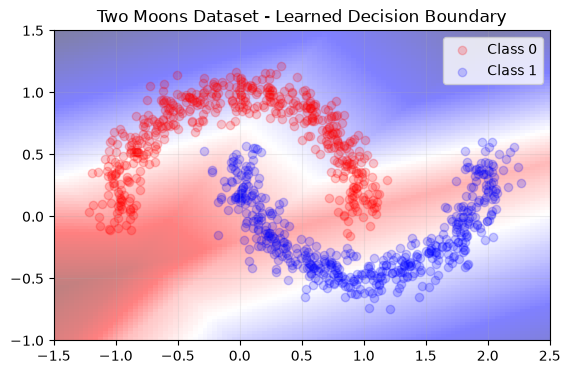

In [14]:
# Plot the scatter plot and the decision boundary for Model 1

plt.imshow(
    makeGridPrediction(model_1l, pred_array),
    extent=[x0_grid[0], x0_grid[-1], x1_grid[0], x1_grid[-1]],
    cmap='seismic_r',
    alpha=0.5)

# Plot the data again
class_colors = ["red", "blue"]
for i in range(len(np.unique(y_data))):
    plt.scatter(
        x_data[y_data == i, 0],
        x_data[y_data == i, 1],
        color=class_colors[i],
        alpha=0.2,
        label="Class "+str(i)
    )

plt.grid(alpha=0.2)
plt.legend()
plt.title("Two Moons Dataset - Learned Decision Boundary")
plt.show()

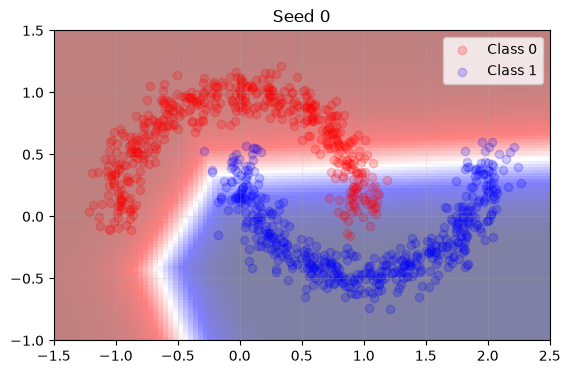

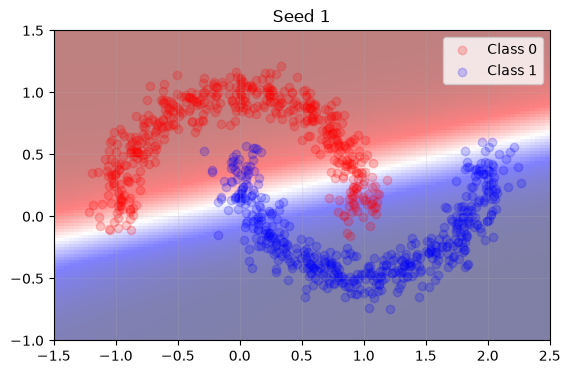

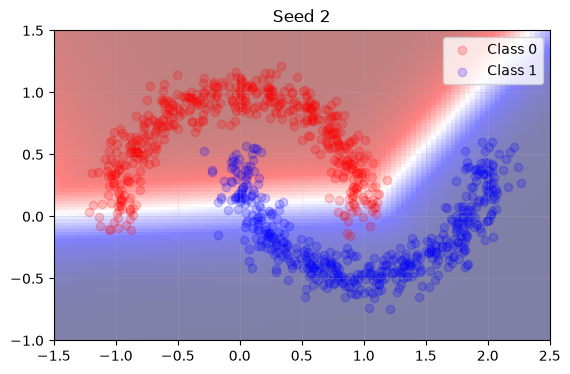

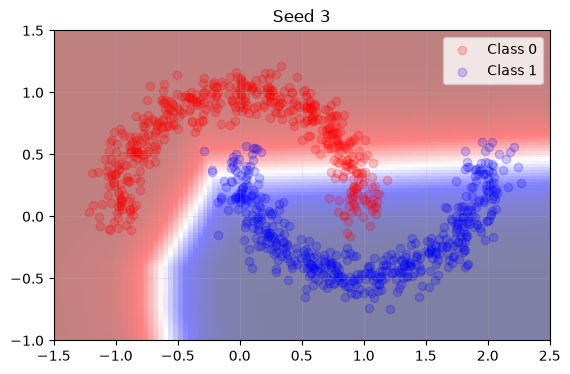

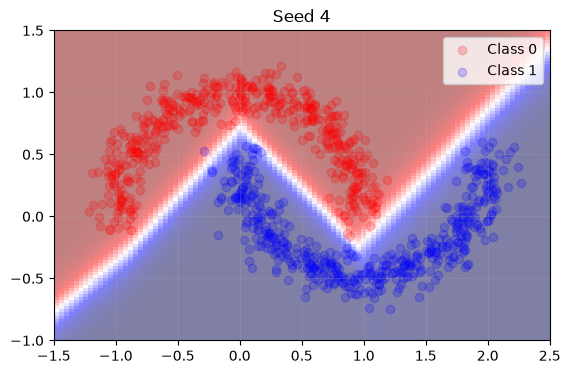

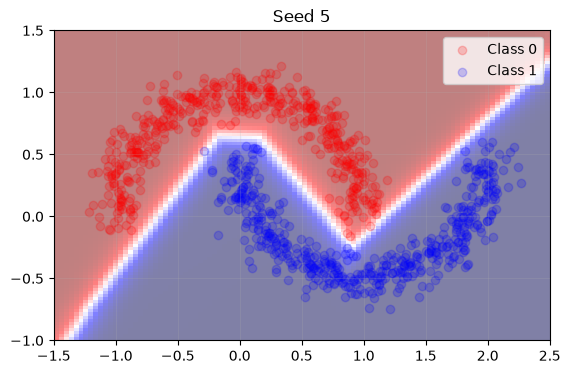

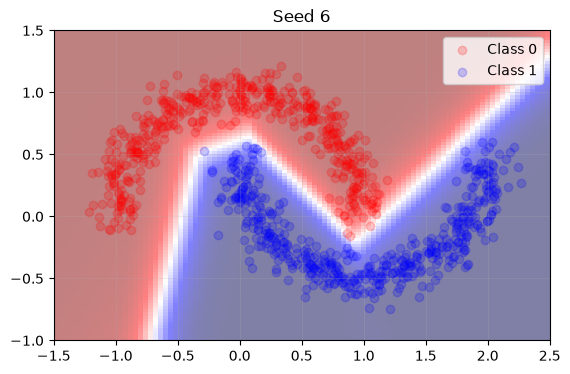

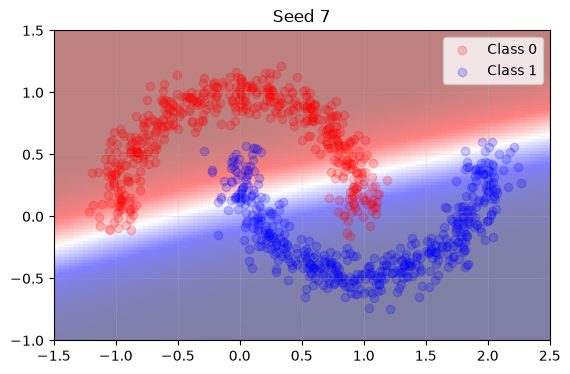

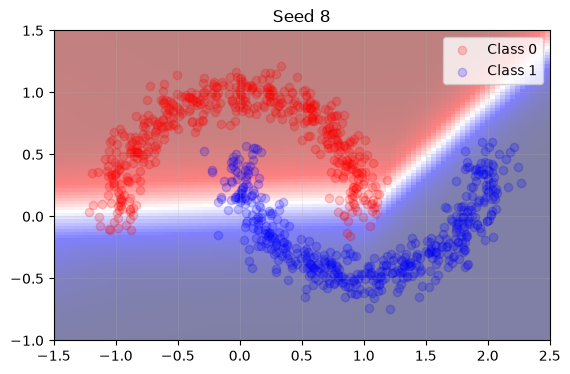

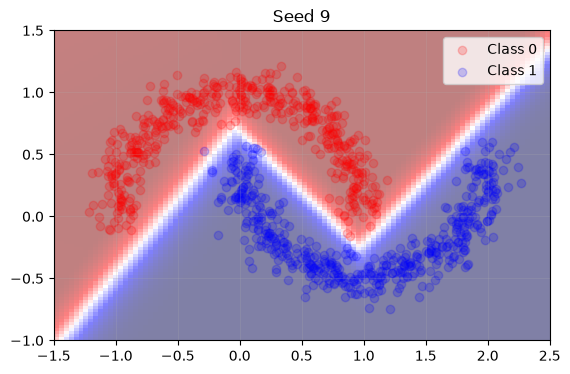

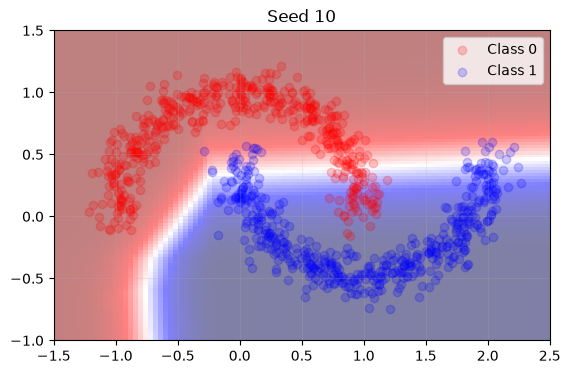

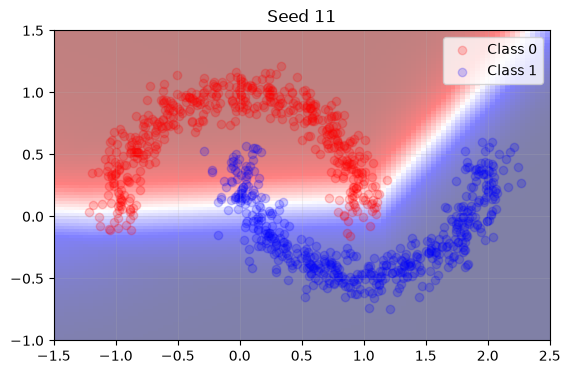

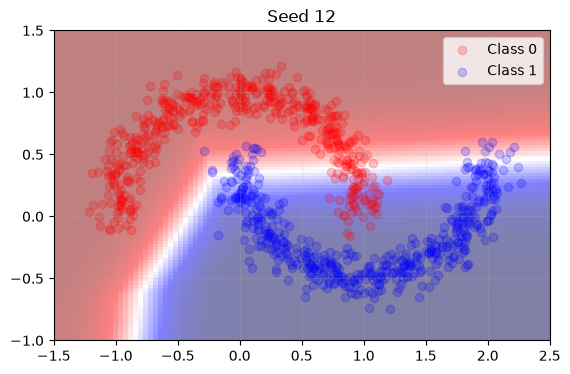

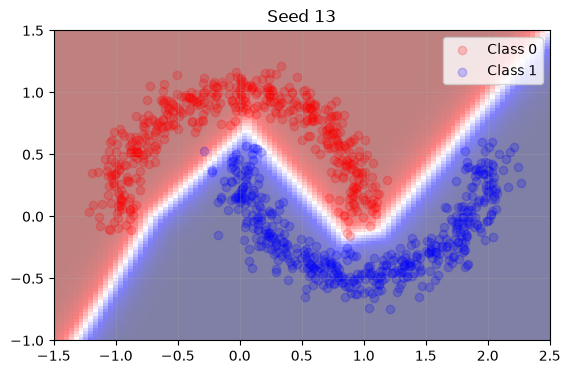

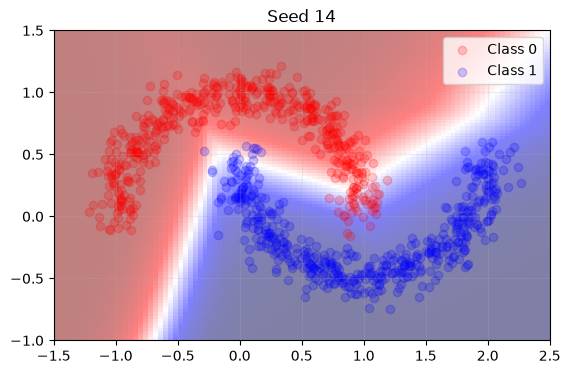

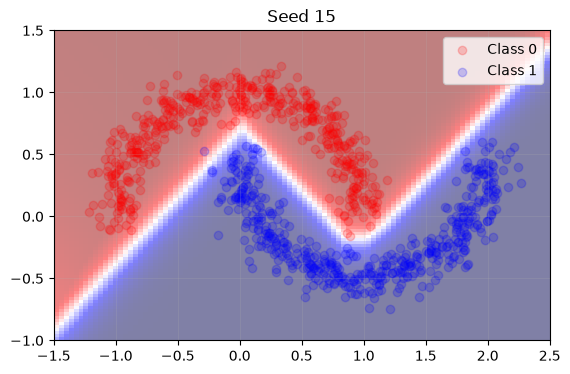

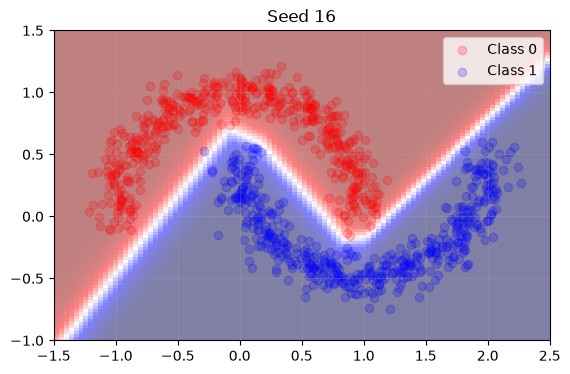

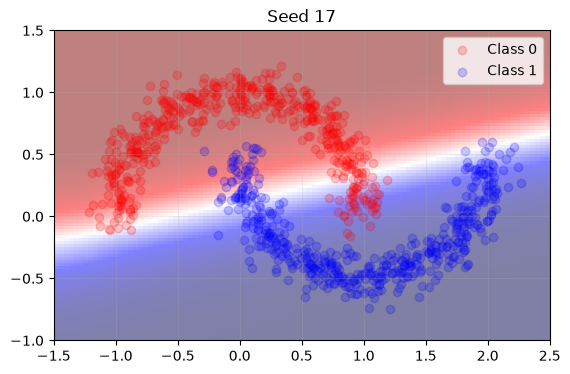

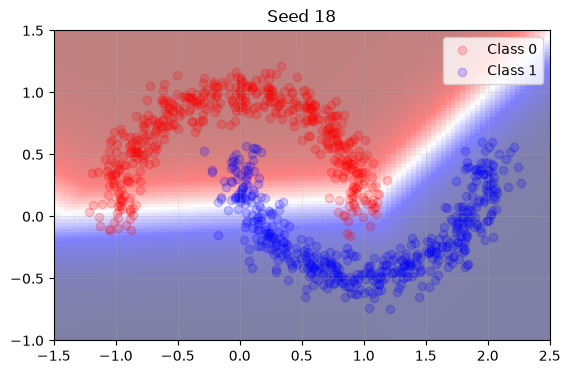

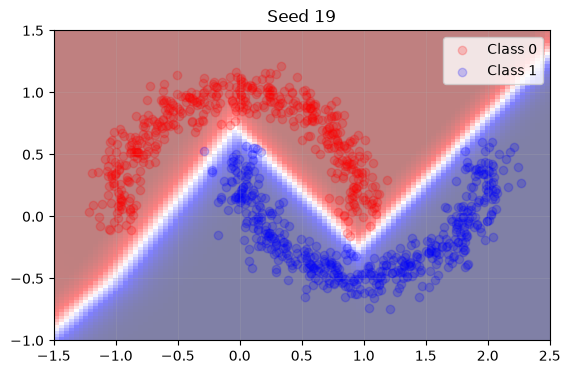

In [ ]:
# test many seeds

for seed in range(20):
    model_2l = train(model_2l, two_moons, show_loss=False, set_seed=seed)

    # Plot the scatter plot and the decision boundary for Model 2
    plt.imshow(
        makeGridPrediction(model_2l, pred_array),
        extent=[x0_grid[0], x0_grid[-1], x1_grid[0], x1_grid[-1]],
        cmap='seismic_r',
        alpha=0.5)

    # Plot the data again
    class_colors = ["red", "blue"]
    for i in range(len(np.unique(y_data))):
        plt.scatter(
            x_data[y_data == i, 0],
            x_data[y_data == i, 1],
            color=class_colors[i],
            alpha=0.2,
            label="Class "+str(i)
        )

    plt.grid(alpha=0.2)
    plt.legend()
    plt.title(f'Seed {seed}')
    plt.show()

In [16]:
model_2l = train(model_2l, two_moons, show_loss=True, set_seed=4)

Initial Loss: 0.26006007194519043
Initial Accuracy: 0.5 

Epoch: 01/50 | Loss: 0.25681 	 | Accuracy: 0.50200
Epoch: 02/50 | Loss: 0.24583 	 | Accuracy: 0.57800
Epoch: 03/50 | Loss: 0.23319 	 | Accuracy: 0.60100
Epoch: 04/50 | Loss: 0.20129 	 | Accuracy: 0.78200
Epoch: 05/50 | Loss: 0.14526 	 | Accuracy: 0.82300
Epoch: 06/50 | Loss: 0.10144 	 | Accuracy: 0.86100
Epoch: 07/50 | Loss: 0.08812 	 | Accuracy: 0.87400
Epoch: 08/50 | Loss: 0.08376 	 | Accuracy: 0.87500
Epoch: 09/50 | Loss: 0.08007 	 | Accuracy: 0.88000
Epoch: 10/50 | Loss: 0.07706 	 | Accuracy: 0.88300
Epoch: 11/50 | Loss: 0.07468 	 | Accuracy: 0.89000
Epoch: 12/50 | Loss: 0.07223 	 | Accuracy: 0.89600
Epoch: 13/50 | Loss: 0.06933 	 | Accuracy: 0.90400
Epoch: 14/50 | Loss: 0.06589 	 | Accuracy: 0.90800
Epoch: 15/50 | Loss: 0.06179 	 | Accuracy: 0.91500
Epoch: 16/50 | Loss: 0.05729 	 | Accuracy: 0.92100
Epoch: 17/50 | Loss: 0.05225 	 | Accuracy: 0.93300
Epoch: 18/50 | Loss: 0.04684 	 | Accuracy: 0.93800
Epoch: 19/50 | Loss: 0.0

Manim Community v0.20.1

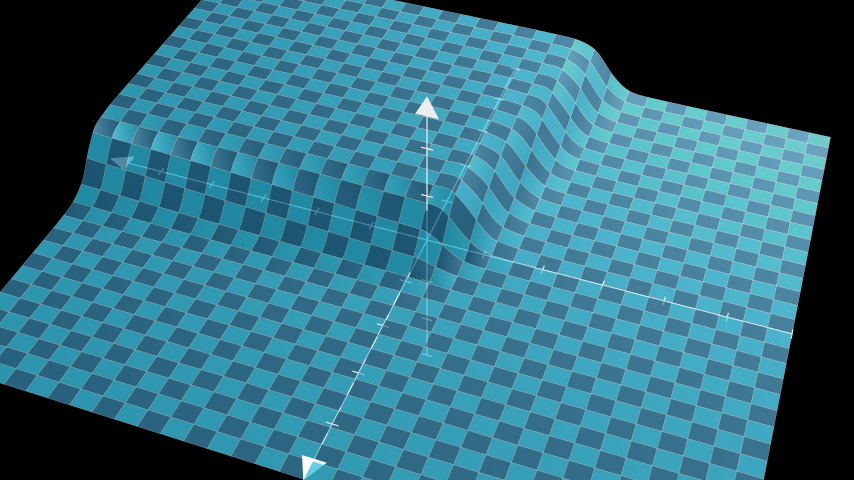

In [349]:
%%manim -s -ql -v WARNING NN_plane_visualization
#%%manim -ql -v WARNING NN_plane_visualization

# 2 layer, full network outputs


class NN_plane_visualization(ThreeDScene):
    def construct(self):
        axes_3d = ThreeDAxes(
            x_range=(-6,6,1),
            x_length=12,
            y_range=(-5,5,1),
            y_length=10,
            z_range=(-3,3,1),
            z_length=6
        )
        self.add(axes_3d)
        self.set_camera_orientation(phi=60*DEGREES, theta=-45*DEGREES)

        def curry_compute_location(model):
            def f(u, v):
                prediction = model(torch.from_numpy(np.array([u,v]) ).float() )
                z = prediction.item()
                return np.array([u,v,z])
            return f

        compute_location = curry_compute_location_fast(model_2l, u_range=[-6,6], v_range=[-5,5], normalize=False)

        model_surface = Surface(
            compute_location,
            u_range=[-6,6],
            v_range=[-5,5]
        ).set_opacity(0.8)

        self.add(
            axes_3d,model_surface
        )

        self.move_camera(phi=45*DEGREES, theta=110*DEGREES,run_time=3)

In [18]:
%%manim -ql -v WARNING input_plane_visualization
# 2d input plane visualization

class input_plane_visualization(Scene):
    def construct(self):
        left_bound = -2
        right_bound = 3
        bottom_bound = -1
        top_bound = 2

        axes = Axes(
            x_range=(left_bound,right_bound,1),
            x_length=8,
            y_range=(bottom_bound,top_bound,1),
            y_length=6
        )
        self.add(axes)

        two_moons_red = VGroup(*[Dot(axes.c2p(point), radius=0.05) for point in x_data[y_data == 0]]).set_color(RED_C)
        two_moons_blue = VGroup(*[Dot(axes.c2p(point), radius=0.05) for point in x_data[y_data == 1]]).set_color(BLUE_D)

        self.add(two_moons_red)
        self.add(two_moons_blue)

        grid_resolution = (200,200)
        model = model_2l

        l1_contours = find_model_contours(model, [-2,3], [-1,2], grid_resolution=grid_resolution, layer=0)
        l1_nodes = VGroup(*[VMobject().set_points_as_corners([
            axes.c2p(x, y) for x, y in node
        ]) for node in l1_contours if len(node) > 0])
        self.add(l1_nodes)

        self.wait(2)

        l2_contours = find_model_contours(model, [-2,3], [-1,2], grid_resolution=grid_resolution, layer=2)
        l2_nodes = VGroup(*[VMobject().set_points_as_corners([
            axes.c2p(x, y) for x, y in node
        ]) for node in l2_contours if len(node) > 0])
        self.add(l2_nodes)

        self.wait(3)

        l3_contours = find_model_contours(model, [-2,3], [-1,2], grid_resolution=grid_resolution, layer=None)
        l3_nodes = VGroup(*[VMobject().set_points_as_corners([
            axes.c2p(x, y) for x, y in node
        ]) for node in l3_contours if len(node) > 0])
        self.add(l3_nodes)

        self.wait(5)
        


Manim Community v0.20.1

In [ ]:
%%manim -ql -v WARNING input_plane_visualization

import copy

class input_plane_visualization(Scene):
    def construct(self):

        # Set up axes and data
        left_bound = -2
        right_bound = 3
        bottom_bound = -1
        top_bound = 2

        axes = Axes(
            x_range=(left_bound, right_bound, 1),
            x_length=8,
            y_range=(bottom_bound, top_bound, 1),
            y_length=6,
        )

        self.add(axes)

        # MAKE LOAD_DATASET FUNC IN PERIPHERAL FILE
        two_moons_red = VGroup(*[
            Dot(axes.c2p(point), radius=0.05)
            for point in x_data[y_data == 0]
        ]).set_color(RED_C)

        two_moons_blue = VGroup(*[
            Dot(axes.c2p(point), radius=0.05)
            for point in x_data[y_data == 1]
        ]).set_color(BLUE_D)

        self.add(two_moons_red, two_moons_blue)

        # Load models
        model_start = copy.deepcopy(model_2l)
        model_live = copy.deepcopy(model_start)
        model_end = copy.deepcopy(model_2l)

        # Example modification
        with torch.no_grad():
            model_end[0].weight += 0.7 * torch.randn_like(model_end[0].weight)
            model_end[0].bias += 0.4 * torch.randn_like(model_end[0].bias)
            
        # Initialize contours
        grid_resolution = (200, 200)

        l1_contours = find_model_contours(
            model_live,
            [-2, 3],
            [-1, 2],
            grid_resolution=grid_resolution,
            layer=0,
        )

        l1_nodes = VGroup()
        for contour in l1_contours:
            mob = VMobject()
            if len(contour) > 0:
                mob.set_points_as_corners([
                    axes.c2p(x, y)
                    for x, y in contour
                ])
            l1_nodes.add(mob)


        l2_contours = find_model_contours(
            model_live,
            [-2, 3],
            [-1, 2],
            grid_resolution=grid_resolution,
            layer=2,
        )

        l2_nodes = VGroup()
        for contour in l2_contours:
            mob = VMobject()
            if len(contour) > 0:
                mob.set_points_as_corners([
                    axes.c2p(x, y)
                    for x, y in contour
                ])
            l2_nodes.add(mob)



        # Create model updater
        alpha = ValueTracker(0)
        model_updater = Mobject() # this updates the model weights every frame

        # PUT UPDATER FUNCTIONS IN PERIPHERAL FILE if possible
        def interpolate_model(_):
            t = alpha.get_value() # t determines how far between model_start and model_end we are

            with torch.no_grad():
                for p_live, p0, p1 in zip(
                    model_live.parameters(),
                    model_start.parameters(),
                    model_end.parameters()
                ):
                    p_live.copy_(torch.lerp(p0, p1, t)) # updates model in place w/ interpolated parameters

        model_updater.add_updater(interpolate_model)
        self.add(model_updater)

        # Create contour updater
        def update_contours_l1(group):

            # recompute contours
            contours = find_model_contours(
                model_live,
                [-2, 3],
                [-1, 2],
                grid_resolution=grid_resolution,
                layer=0,
            )

            # update each node to display correct contour
            for mob, contour in zip(group, contours):
                if len(contour) == 0:
                    mob.clear_points()
                    continue
                mob.set_points_as_corners([
                    axes.c2p(x, y)
                    for x, y in contour
                ])
        
        def update_contours_l2(group):

            # recompute contours
            contours = find_model_contours(
                model_live,
                [-2, 3],
                [-1, 2],
                grid_resolution=grid_resolution,
                layer=2,
            )

            # update each node to display correct contour
            for mob, contour in zip(group, contours):
                if len(contour) == 0:
                    mob.clear_points()
                    continue
                mob.set_points_as_corners([
                    axes.c2p(x, y)
                    for x, y in contour
                ])

        l1_nodes.add_updater(update_contours_l1)
        self.add(l1_nodes)

        l2_nodes.add_updater(update_contours_l2)
        self.add(l2_nodes)



        # Animate
        self.wait()

        self.play(
            alpha.animate.set_value(1),
            run_time=5,
            rate_func=smooth,
        )

        self.wait()

Manim Community v0.20.1